# Notebook 4: Perbandingan Model dan Metode

Notebook ini melengkapi 3 notebook sebelumnya dengan **perbandingan eksplisit** antara metode/model yang dipakai di pipeline utama versus alternatif lain. Tujuannya bukan mengganti pipeline final, melainkan memberi bukti empiris kenapa pilihan di Notebook 1-3 lebih baik (atau menunjukkan bila ternyata ada alternatif yang lebih layak dipertimbangkan).

Empat perbandingan yang dilakukan:

1. **Lokalisasi Dokumen**: DocAligner (dipakai di pipeline) vs heuristik CV klasik (Canny edge + contour detection + perspective warp)
2. **OCR Engine**: PaddleOCR (dipakai di pipeline) vs EasyOCR vs Tesseract
3. **Model Klasifikasi Field**: LightGBM (dipakai di pipeline) vs RandomForest vs XGBoost, dengan fitur spasial+numerik yang sama persis
4. **Paradigma Representasi Teks**: TF-IDF + Logistic Regression (representasi teks murni) vs fitur spasial+numerik + LightGBM (pendekatan pipeline) vs baseline rule-based/regex

Notebook ini didesain untuk **reuse** artefak yang sudah dihasilkan Notebook 1-3 (`fold_indices.pkl`, `master_features.csv`, `ocr_segments_features.csv`, `ground_truth_normalized.csv`, folder `cropped_images`) supaya perbandingan adil menggunakan split data dan fitur yang identik. Jalankan notebook ini setelah Notebook 1, 2, dan 3 selesai dijalankan minimal sekali (agar file cache tersedia).


## 0. Setup

In [2]:
import os
import re
import cv2
import json
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import Levenshtein as lev
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_recall_fscore_support, classification_report

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
PALETTE = 'muted'
sns.set_palette(PALETTE)
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})

# Path-path ini mengikuti struktur yang sama dengan Notebook 1-3
DATASET_DIR   = 'dataset'
IMG_DIR       = os.path.join(DATASET_DIR, 'images')
CROPPED_DIR   = os.path.join(DATASET_DIR, 'cropped_images')          # hasil DocAligner (Notebook 2)
CLASSICAL_DIR = os.path.join(DATASET_DIR, 'cropped_images_classical') # hasil heuristik CV klasik (notebook ini)
GT_PATH       = os.path.join(DATASET_DIR, 'ground_truth_normalized.csv')
MASTER_PATH   = os.path.join(DATASET_DIR, 'master_features.csv')
SEGMENTS_PATH = os.path.join(DATASET_DIR, 'ocr_segments_features.csv')
FOLD_PATH     = os.path.join(DATASET_DIR, 'fold_indices.pkl')
COMPARISON_DIR = os.path.join(DATASET_DIR, 'model_comparison_results')

os.makedirs(CLASSICAL_DIR, exist_ok=True)
os.makedirs(COMPARISON_DIR, exist_ok=True)

FEATURE_COLS = [
    'y_rel_scaled', 'x_rel_scaled', 'width_rel_scaled',
    'text_len', 'word_count',
    'ocr_conf', 'alpha_ratio', 'digit_ratio', 'is_all_caps',
    'has_date_pattern', 'has_address_kw', 'has_state_kw',
    'has_postcode', 'has_bin_binti', 'line_rank_norm',
    'doc_origin_encoded',
]
LABEL_MAP     = {'other': 0, 'name': 1, 'birth_date': 2, 'address': 3}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

print('Setup selesai.')


Setup selesai.


### Memuat artefak dari Notebook 1-3

Kita pakai ulang `fold_indices.pkl` (pembagian StratifiedGroupKFold yang sama), `master_features.csv`, dan `ocr_segments_features.csv` supaya semua perbandingan model di notebook ini diuji dengan split dan fitur yang identik dengan pipeline utama -- ini penting agar perbandingan adil (apple-to-apple), bukan cuma beda random seed.

In [3]:
df_gt = pd.read_csv(GT_PATH)

df          = pd.read_csv(MASTER_PATH)
df_segments = pd.read_csv(SEGMENTS_PATH)

with open(FOLD_PATH, 'rb') as f:
    folds = pickle.load(f)

print(f'Ground truth   : {len(df_gt)} baris')
print(f'Master features: {len(df)} gambar')
print(f'Segmen OCR     : {len(df_segments)} segmen teks')
print(f'Jumlah fold    : {len(folds)}')


Ground truth   : 632 baris
Master features: 632 gambar
Segmen OCR     : 11405 segmen teks
Jumlah fold    : 5


## 1. Lokalisasi Dokumen: DocAligner vs Heuristik CV Klasik

Pipeline utama (Notebook 2) memakai **DocAligner**, model deep learning untuk mencari 4 sudut kartu identitas secara langsung dari piksel gambar. Sebagai pembanding, kita bangun heuristik CV klasik yang umum dipakai sebelum era deep learning: **Canny edge detection -> contour detection -> ambil contour 4 sisi terbesar -> perspective warp**.

Yang dibandingkan:
- **Tingkat keberhasilan** menemukan kontur kartu (berapa persen gambar yang gagal dan harus fallback ke gambar penuh)
- **Kualitas hasil crop** (blur score, edge density) dibanding hasil DocAligner yang sudah tersimpan di `master_features.csv`
- **Efek downstream ke OCR** (CER pembacaan teks) sebagai bukti akhir mana yang benar-benar lebih baik dipakai

In [7]:
def localize_card_classical(img: np.ndarray, target_ratio: float = 1.586):
    """
    Heuristik CV klasik untuk menemukan dan meluruskan kartu identitas.
    target_ratio: rasio lebar/tinggi kartu ID standar (mendekati ISO/IEC 7810 ID-1, ~85.6/54).

    Return: (cropped_image, success_flag)
    """
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blurred, 50, 150)
    edges   = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=1)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img, False

    img_area = img.shape[0] * img.shape[1]
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    best_quad = None
    for c in contours:
        area = cv2.contourArea(c)
        # kartu identitas biasanya menutupi porsi cukup besar dari foto tapi bukan seluruhnya
        if area < 0.1 * img_area or area > 0.98 * img_area:
            continue
        peri   = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            best_quad = approx.reshape(4, 2).astype(np.float32)
            break

    if best_quad is None:
        return img, False

    # urutkan 4 titik: top-left, top-right, bottom-right, bottom-left
    s    = best_quad.sum(axis=1)
    diff = np.diff(best_quad, axis=1).flatten()
    tl   = best_quad[np.argmin(s)]
    br   = best_quad[np.argmax(s)]
    tr   = best_quad[np.argmin(diff)]
    bl   = best_quad[np.argmax(diff)]
    src  = np.array([tl, tr, br, bl], dtype=np.float32)

    width_a  = np.linalg.norm(br - bl)
    width_b  = np.linalg.norm(tr - tl)
    max_w    = max(int(width_a), int(width_b), 1)
    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_h    = max(int(height_a), int(height_b), 1)

    dst = np.array([[0, 0], [max_w - 1, 0], [max_w - 1, max_h - 1], [0, max_h - 1]], dtype=np.float32)
    M   = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(img, M, (max_w, max_h))

    return warped, True


def compute_crop_quality(img):
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
    edges = cv2.Canny(gray, 50, 150)
    return {
        'blur_score':   float(cv2.Laplacian(gray, cv2.CV_64F).var()),
        'brightness':   float(gray.mean()),
        'contrast':     float(gray.std()),
        'edge_density': float(edges.mean()),
    }

print('Fungsi heuristik CV klasik siap.')


Fungsi heuristik CV klasik siap.


In [8]:
MANIFEST_PATH = os.path.join(DATASET_DIR, 'classical_localization_manifest.csv')

if os.path.exists(MANIFEST_PATH):
    df_classical = pd.read_csv(MANIFEST_PATH)
else:
    classical_log = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Lokalisasi klasik'):
        fname = row['filename']
        out_path = os.path.join(CLASSICAL_DIR, fname)
        path = os.path.join(IMG_DIR, fname)
        img = cv2.imread(path) if os.path.exists(path) else None
        if img is None:
            classical_log.append({'filename': fname, 'classical_success': False})
            continue

        cropped, success = localize_card_classical(img)
        cv2.imwrite(out_path, cropped)
        q = compute_crop_quality(cropped)
        classical_log.append({'filename': fname, 'classical_success': success, **q})

    df_classical = pd.DataFrame(classical_log)
    df_classical.to_csv(MANIFEST_PATH, index=False)  # <- simpan status asli, sekali untuk semua

success_rate = df_classical['classical_success'].mean()
print(f'Tingkat keberhasilan: {success_rate:.1%}')

Lokalisasi klasik: 100%|██████████| 632/632 [01:32<00:00,  6.85it/s]

Tingkat keberhasilan: 3.5%


               Metode  Blur Score (mean)  Edge Density (mean)  Contrast (mean)  Tingkat Sukses
DocAligner (pipeline)         145.726371            10.737407        31.399426        0.707278
  Heuristik CV Klasik         177.462301             8.854301        36.038283        0.034810


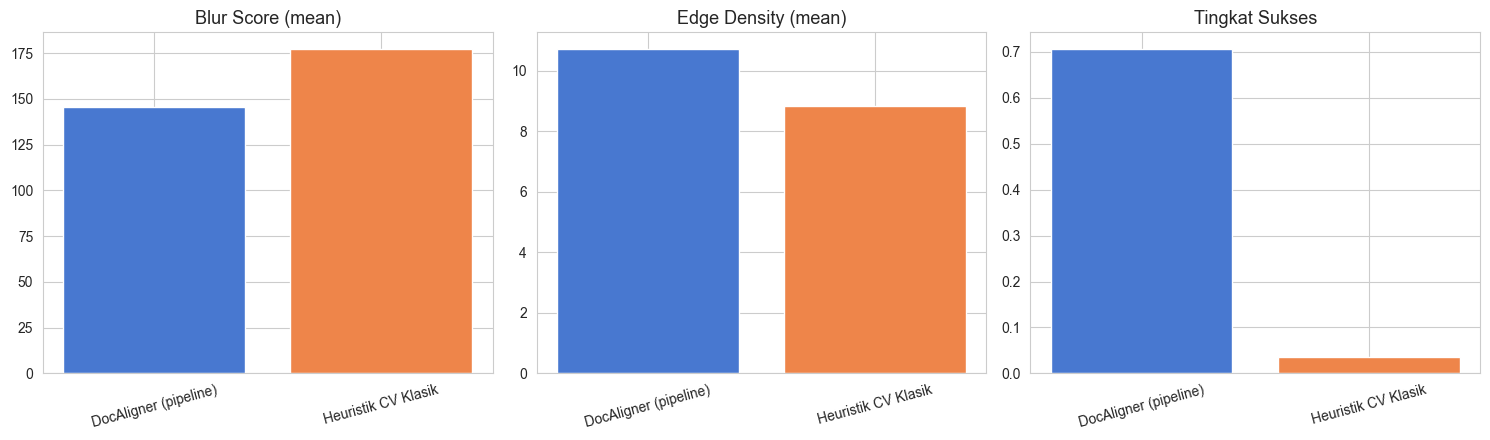

In [10]:
if 'localization_method' in df.columns:
    docaligner_success_rate = (df['localization_method'] == 'docaligner').mean()
else:
    print('PERINGATAN: kolom localization_method tidak ada di master_features.csv, '
          'perlu di-merge ulang dari df_loc di Notebook 2.')
    docaligner_success_rate = np.nan

comparison_quality = pd.DataFrame({
    'Metode':          ['DocAligner (pipeline)', 'Heuristik CV Klasik'],
    'Blur Score (mean)':   [df['crop_blur_score'].mean(),  df_classical['blur_score'].mean()],
    'Edge Density (mean)': [df['crop_edge_density'].mean(), df_classical['edge_density'].mean()],
    'Contrast (mean)':     [df['crop_contrast'].mean(),     df_classical['contrast'].mean()],
    'Tingkat Sukses':      [docaligner_success_rate, success_rate],
})
print(comparison_quality.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_to_plot = ['Blur Score (mean)', 'Edge Density (mean)', 'Tingkat Sukses']
colors = sns.color_palette(PALETTE, 2)
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison_quality['Metode'], comparison_quality[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_DIR, 'localization_quality_comparison.png'), dpi=100)
plt.show()


### Efek downstream ke OCR (opsional, lebih berat)

Bukti paling meyakinkan bukan cuma metrik kualitas gambar, tapi seberapa besar dampaknya ke akurasi pembacaan teks. Sel di bawah menjalankan PaddleOCR pada subset kecil hasil crop klasik dan membandingkan CER nama terhadap hasil OCR yang sudah di-cache dari crop DocAligner (`raw_ocr_lib.pkl` di Notebook 2).

In [4]:
N_SAMPLE = 60  # jumlah gambar yang diuji ulang untuk efek downstream

def compute_cer(hyp: str, ref: str) -> float:
    ref_str = str(ref).strip().lower()
    hyp_str = str(hyp).strip().lower()
    if len(ref_str) == 0:
        return 0.0 if len(hyp_str) == 0 else 1.0
    return lev.distance(hyp_str, ref_str) / len(ref_str)

try:
    from paddleocr import PaddleOCR
    ocr_engine = PaddleOCR(use_angle_cls=True, lang='pt')

    RAW_OCR_CACHE = os.path.join(DATASET_DIR, 'raw_ocr_lib.pkl')
    with open(RAW_OCR_CACHE, 'rb') as f:
        raw_ocr_results = pickle.load(f)

    sample_files = df['filename'].sample(n=min(N_SAMPLE, len(df)), random_state=42).tolist()

    rows = []
    for fname in tqdm(sample_files, desc='OCR pada crop klasik'):
        classical_path = os.path.join(CLASSICAL_DIR, fname)
        if not os.path.exists(classical_path):
            continue
        img = cv2.imread(classical_path)
        res = ocr_engine.predict(img) if hasattr(ocr_engine, 'predict') else ocr_engine.predict(img)
        if hasattr(res[0], 'keys') and 'rec_texts' in res[0].keys():
            texts_classical = res[0].get('rec_texts', [])
        else:
            texts_classical = [line[1][0] for line in res[0]] if res and res[0] else []
        text_classical = ' '.join(texts_classical)

        text_docaligner = ' '.join(raw_ocr_results.get(fname, {}).get('texts', []))

        ref_row = df_gt[df_gt['filename'] == fname]
        if ref_row.empty:
            continue
        ref_name = str(ref_row.iloc[0]['name'])

        rows.append({
            'filename': fname,
            'cer_docaligner_crop': compute_cer(text_docaligner, ref_name),
            'cer_classical_crop':  compute_cer(text_classical, ref_name),
        })

    df_downstream = pd.DataFrame(rows)
    print(df_downstream[['cer_docaligner_crop', 'cer_classical_crop']].mean().to_string())
    df_downstream.to_csv(os.path.join(COMPARISON_DIR, 'localization_downstream_cer.csv'), index=False)

except ImportError:
    print('PaddleOCR tidak tersedia di environment ini -- lewati pengujian downstream OCR.')
except FileNotFoundError:
    print('raw_ocr_lib.pkl belum ada -- jalankan Notebook 2 terlebih dahulu untuk menghasilkan cache OCR DocAligner.')


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually

RuntimeError: Unknown exception

## 2. OCR Engine: PaddleOCR vs EasyOCR vs Tesseract

Pipeline utama memakai PaddleOCR. Di sini kita jalankan ketiga engine OCR konvensional (semuanya diizinkan sesuai guideline final project) pada gambar crop yang sama (hasil DocAligner), lalu bandingkan CER, WER, dan waktu proses rata-rata. Semua dievaluasi terhadap kolom `name` di ground truth sebagai referensi teks utama.

In [12]:
N_SAMPLE_OCR = 80

def compute_wer(hyp: str, ref: str) -> float:
    ref_words = str(ref).strip().lower().split()
    hyp_words = str(hyp).strip().lower().split()
    if len(ref_words) == 0:
        return 0.0 if len(hyp_words) == 0 else 1.0
    return lev.distance(' '.join(hyp_words), ' '.join(ref_words)) / len(ref_words)

sample_files_ocr = df['filename'].sample(n=min(N_SAMPLE_OCR, len(df)), random_state=42).tolist()
ocr_results = []

# --- PaddleOCR ---
try:
    from paddleocr import PaddleOCR
    engine_paddle = PaddleOCR(use_angle_cls=True, lang='en', device='cpu')
    for fname in tqdm(sample_files_ocr, desc='PaddleOCR'):
        path = os.path.join(CROPPED_DIR, fname)
        if not os.path.exists(path):
            continue
        img = cv2.imread(path)
        t0 = time.time()
        res = engine_paddle.predict(img) if hasattr(engine_paddle, 'predict') else engine_paddle.ocr(img)
        elapsed = time.time() - t0
        if hasattr(res[0], 'keys') and 'rec_texts' in res[0].keys():
            texts = res[0].get('rec_texts', [])
        else:
            texts = [line[1][0] for line in res[0]] if res and res[0] else []
        ref_row = df_gt[df_gt['filename'] == fname]
        ref_name = str(ref_row.iloc[0]['name']) if not ref_row.empty else ''
        ocr_results.append({'engine': 'PaddleOCR', 'filename': fname, 'text': ' '.join(texts),
                             'ref_name': ref_name, 'latency_sec': elapsed})
except ImportError:
    print('PaddleOCR tidak tersedia, dilewati.')

# --- EasyOCR ---
try:
    import easyocr
    engine_easy = easyocr.Reader(['en'], gpu=False)
    for fname in tqdm(sample_files_ocr, desc='EasyOCR'):
        path = os.path.join(CROPPED_DIR, fname)
        if not os.path.exists(path):
            continue
        img = cv2.imread(path)
        t0 = time.time()
        res = engine_easy.readtext(img)
        elapsed = time.time() - t0
        texts = [r[1] for r in res]
        ref_row = df_gt[df_gt['filename'] == fname]
        ref_name = str(ref_row.iloc[0]['name']) if not ref_row.empty else ''
        ocr_results.append({'engine': 'EasyOCR', 'filename': fname, 'text': ' '.join(texts),
                             'ref_name': ref_name, 'latency_sec': elapsed})
except ImportError:
    print('EasyOCR tidak terpasang -- install dengan `pip install easyocr` bila ingin membandingkan.')

# --- Tesseract ---
try:
    import pytesseract
    for fname in tqdm(sample_files_ocr, desc='Tesseract'):
        path = os.path.join(CROPPED_DIR, fname)
        if not os.path.exists(path):
            continue
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        t0 = time.time()
        text = pytesseract.image_to_string(gray)
        elapsed = time.time() - t0
        ref_row = df_gt[df_gt['filename'] == fname]
        ref_name = str(ref_row.iloc[0]['name']) if not ref_row.empty else ''
        ocr_results.append({'engine': 'Tesseract', 'filename': fname, 'text': text.replace(chr(10), ' '),
                             'ref_name': ref_name, 'latency_sec': elapsed})
except ImportError:
    print('pytesseract tidak terpasang -- install dengan `pip install pytesseract` dan binary Tesseract OCR bila ingin membandingkan.')

df_ocr_compare = pd.DataFrame(ocr_results)
if not df_ocr_compare.empty:
    df_ocr_compare['cer'] = df_ocr_compare.apply(lambda r: compute_cer(r['text'], r['ref_name']), axis=1)
    df_ocr_compare['wer'] = df_ocr_compare.apply(lambda r: compute_wer(r['text'], r['ref_name']), axis=1)
    df_ocr_compare.to_csv(os.path.join(COMPARISON_DIR, 'ocr_engine_raw_results.csv'), index=False)
print(f'Total hasil terkumpul: {len(df_ocr_compare)}')


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\visco\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Tesseract: 100%|██████████| 80/80 [00:00<00:00, 48841.97it/s]

Total hasil terkumpul: 0


In [13]:
if not df_ocr_compare.empty:
    summary_ocr = df_ocr_compare.groupby('engine').agg(
        cer_mean=('cer', 'mean'),
        wer_mean=('wer', 'mean'),
        latency_mean=('latency_sec', 'mean'),
    ).round(4)
    print(summary_ocr.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    colors = sns.color_palette(PALETTE, len(summary_ocr))
    for ax, col, title in zip(axes, ['cer_mean', 'wer_mean', 'latency_mean'],
                               ['CER rata-rata (makin rendah makin baik)',
                                'WER rata-rata (makin rendah makin baik)',
                                'Latensi rata-rata (detik/gambar)']):
        ax.bar(summary_ocr.index, summary_ocr[col], color=colors)
        ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(COMPARISON_DIR, 'ocr_engine_comparison.png'), dpi=100)
    plt.show()
else:
    print('Tidak ada engine OCR yang berhasil dijalankan -- pastikan minimal satu library terpasang.')


Tidak ada engine OCR yang berhasil dijalankan -- pastikan minimal satu library terpasang.


## 3. Model Klasifikasi Field: LightGBM vs RandomForest vs XGBoost

Ini perbandingan yang paling apple-to-apple: ketiga model dilatih pada fitur spasial+numerik yang **identik** (`FEATURE_COLS`, sama seperti Notebook 3) dan fold split yang **identik** (`fold_indices.pkl`), sehingga selisih performa murni berasal dari algoritmanya, bukan dari perbedaan data atau fitur.

In [14]:
import lightgbm as lgb

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost tidak terpasang -- install dengan `pip install xgboost` untuk mengaktifkan perbandingan ini.')

def get_models():
    models = {
        'LightGBM': lgb.LGBMClassifier(
            objective='multiclass', num_class=4, class_weight='balanced',
            n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    }
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBClassifier(
            objective='multi:softmax', num_class=4,
            n_estimators=100, max_depth=5, learning_rate=0.1,
            random_state=42, eval_metric='mlogloss', verbosity=0)
    return models


model_comparison_rows = []

for fold_idx, fold_dict in enumerate(folds):
    train_idx, test_idx = fold_dict['train'], fold_dict['test']
    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    train_filenames = set(df_train['filename'])
    test_filenames  = set(df_test['filename'])
    df_seg_train = df_segments[df_segments['filename'].isin(train_filenames)].copy()
    df_seg_test  = df_segments[df_segments['filename'].isin(test_filenames)].copy()

    avail_feat = [f for f in FEATURE_COLS if f in df_seg_train.columns]
    X_train = df_seg_train[avail_feat].fillna(0)
    y_train = df_seg_train['label'].map(LABEL_MAP)
    X_test  = df_seg_test[avail_feat].fillna(0)
    y_test  = df_seg_test['label'].map(LABEL_MAP)

    for model_name, model in get_models().items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        y_pred = model.predict(X_test)
        infer_time = time.time() - t0

        macro_f1    = f1_score(y_test, y_pred, average='macro')
        weighted_f1 = f1_score(y_test, y_pred, average='weighted')

        model_comparison_rows.append({
            'fold': fold_idx, 'model': model_name,
            'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'train_time_sec': train_time, 'infer_time_sec': infer_time,
        })
    print(f'Fold {fold_idx + 1}/{len(folds)} selesai.')

df_model_comparison = pd.DataFrame(model_comparison_rows)
df_model_comparison.to_csv(os.path.join(COMPARISON_DIR, 'field_classifier_model_comparison.csv'), index=False)
print(df_model_comparison.groupby('model')[['macro_f1', 'weighted_f1', 'train_time_sec']].mean().round(4).to_string())


Fold 1/5 selesai.
Fold 2/5 selesai.
Fold 3/5 selesai.
Fold 4/5 selesai.
Fold 5/5 selesai.
              macro_f1  weighted_f1  train_time_sec
model                                              
LightGBM        0.8166       0.9265          0.7891
RandomForest    0.7998       0.9137          0.4533
XGBoost         0.8177       0.9274          0.3022


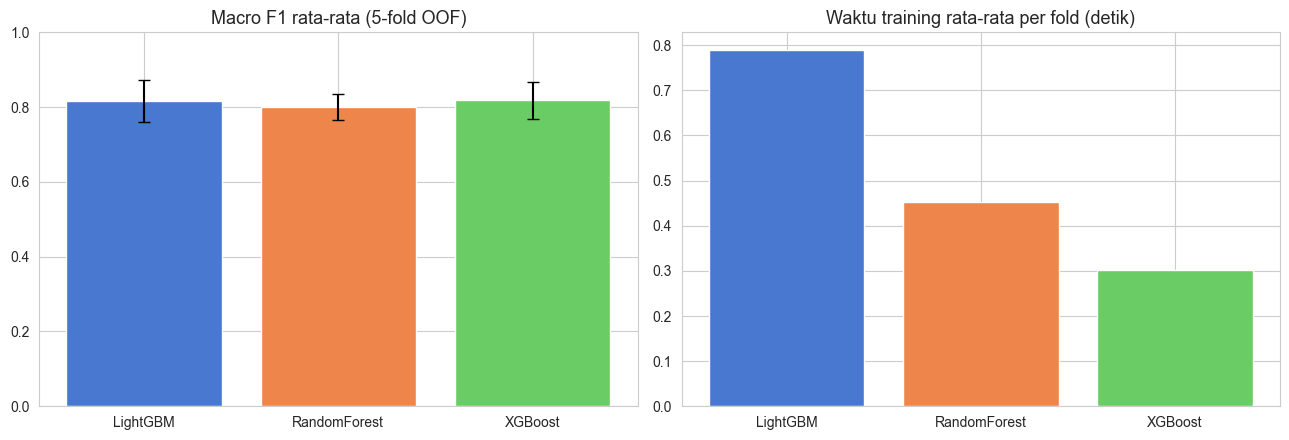

In [15]:
summary_model = df_model_comparison.groupby('model').agg(
    macro_f1_mean=('macro_f1', 'mean'),
    macro_f1_std=('macro_f1', 'std'),
    train_time_mean=('train_time_sec', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = sns.color_palette(PALETTE, len(summary_model))

axes[0].bar(summary_model['model'], summary_model['macro_f1_mean'],
            yerr=summary_model['macro_f1_std'], capsize=4, color=colors)
axes[0].set_title('Macro F1 rata-rata (5-fold OOF)')
axes[0].set_ylim(0, 1)

axes[1].bar(summary_model['model'], summary_model['train_time_mean'], color=colors)
axes[1].set_title('Waktu training rata-rata per fold (detik)')

plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_DIR, 'field_classifier_model_comparison.png'), dpi=100)
plt.show()


## 4. Paradigma Representasi: TF-IDF + Logistic Regression vs Fitur Spasial + LightGBM

Pipeline utama mengklasifikasikan tiap segmen teks hasil OCR (name / birth_date / address / other) berdasarkan **fitur spasial dan numerik** -- posisi relatif di kartu, panjang teks, rasio huruf/angka, dsb -- bukan dari isi teksnya secara langsung. Pertanyaannya: apakah isi teks itu sendiri (lewat TF-IDF) sudah cukup untuk menebak field-nya, atau posisi & bentuk teks yang justru lebih menentukan?

Sebagai pembanding ketiga, kita tambahkan **baseline rule-based/regex** murni tanpa machine learning sama sekali -- baseline paling sederhana yang jadi acuan minimum dalam banyak penelitian information extraction.

In [16]:
def regex_classify_segment(text: str) -> str:
    """Baseline aturan tangan: klasifikasi field murni dari pola teks, tanpa ML sama sekali."""
    t = str(text).strip().upper()
    if not t:
        return 'other'
    # birth_date: mengandung pola tanggal
    if re.search(r'\d{4}-\d{2}-\d{2}', t) or re.search(r'\d{2}/\d{2}/\d{4}', t) or re.fullmatch(r'\d{4}', t):
        return 'birth_date'
    # address: mengandung kata kunci alamat khas Malaysia
    addr_kw = ['JALAN', 'JLN', 'LORONG', 'LRG', 'KAMPUNG', 'KG', 'TAMAN', 'TMN', 'SELANGOR',
               'JOHOR', 'PERAK', 'SABAH', 'SARAWAK', 'KUALA LUMPUR']
    if any(kw in t for kw in addr_kw):
        return 'address'
    # name: didominasi huruf, cukup panjang, tanpa banyak digit
    alpha_ratio = sum(c.isalpha() for c in t) / max(len(t), 1)
    digit_ratio = sum(c.isdigit() for c in t) / max(len(t), 1)
    if alpha_ratio > 0.7 and digit_ratio < 0.1 and len(t) >= 4:
        return 'name'
    return 'other'


tfidf_vs_spatial_rows = []

for fold_idx, fold_dict in enumerate(folds):
    train_idx, test_idx = fold_dict['train'], fold_dict['test']
    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()
    train_filenames = set(df_train['filename'])
    test_filenames  = set(df_test['filename'])
    df_seg_train = df_segments[df_segments['filename'].isin(train_filenames)].copy()
    df_seg_test  = df_segments[df_segments['filename'].isin(test_filenames)].copy()

    y_train = df_seg_train['label'].map(LABEL_MAP)
    y_test  = df_seg_test['label'].map(LABEL_MAP)

    # --- Pendekatan A: TF-IDF + Logistic Regression (representasi teks murni) ---
    text_train = df_seg_train['text'].fillna('').astype(str)
    text_test  = df_seg_test['text'].fillna('').astype(str)

    tfidf_clf = make_pipeline(
        TfidfVectorizer(max_features=500, ngram_range=(1, 2), analyzer='char_wb'),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    )
    tfidf_clf.fit(text_train, y_train)
    y_pred_tfidf = tfidf_clf.predict(text_test)
    f1_tfidf = f1_score(y_test, y_pred_tfidf, average='macro')

    # --- Pendekatan B: Fitur spasial+numerik + LightGBM (pendekatan pipeline utama) ---
    avail_feat = [f for f in FEATURE_COLS if f in df_seg_train.columns]
    X_train = df_seg_train[avail_feat].fillna(0)
    X_test  = df_seg_test[avail_feat].fillna(0)
    spatial_clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=4, class_weight='balanced',
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1)
    spatial_clf.fit(X_train, y_train)
    y_pred_spatial = spatial_clf.predict(X_test)
    f1_spatial = f1_score(y_test, y_pred_spatial, average='macro')

    # --- Pendekatan C: Baseline regex/rule-based (tanpa ML) ---
    y_pred_regex = text_test.apply(regex_classify_segment).map(LABEL_MAP)
    f1_regex = f1_score(y_test, y_pred_regex, average='macro')

    tfidf_vs_spatial_rows.append({'fold': fold_idx, 'approach': 'TF-IDF + LogReg (teks murni)', 'macro_f1': f1_tfidf})
    tfidf_vs_spatial_rows.append({'fold': fold_idx, 'approach': 'Spasial+Numerik + LightGBM (pipeline)', 'macro_f1': f1_spatial})
    tfidf_vs_spatial_rows.append({'fold': fold_idx, 'approach': 'Regex/Rule-based (baseline)', 'macro_f1': f1_regex})

    print(f'Fold {fold_idx + 1}: TF-IDF={f1_tfidf:.3f} | Spasial+LightGBM={f1_spatial:.3f} | Regex={f1_regex:.3f}')

df_paradigm_comparison = pd.DataFrame(tfidf_vs_spatial_rows)
df_paradigm_comparison.to_csv(os.path.join(COMPARISON_DIR, 'text_paradigm_comparison.csv'), index=False)


Fold 1: TF-IDF=0.670 | Spasial+LightGBM=0.905 | Regex=0.459
Fold 2: TF-IDF=0.651 | Spasial+LightGBM=0.779 | Regex=0.428
Fold 3: TF-IDF=0.593 | Spasial+LightGBM=0.815 | Regex=0.423
Fold 4: TF-IDF=0.592 | Spasial+LightGBM=0.760 | Regex=0.464
Fold 5: TF-IDF=0.715 | Spasial+LightGBM=0.823 | Regex=0.437


                             approach     mean      std
Spasial+Numerik + LightGBM (pipeline) 0.816590 0.055886
         TF-IDF + LogReg (teks murni) 0.644203 0.052524
          Regex/Rule-based (baseline) 0.442007 0.018494


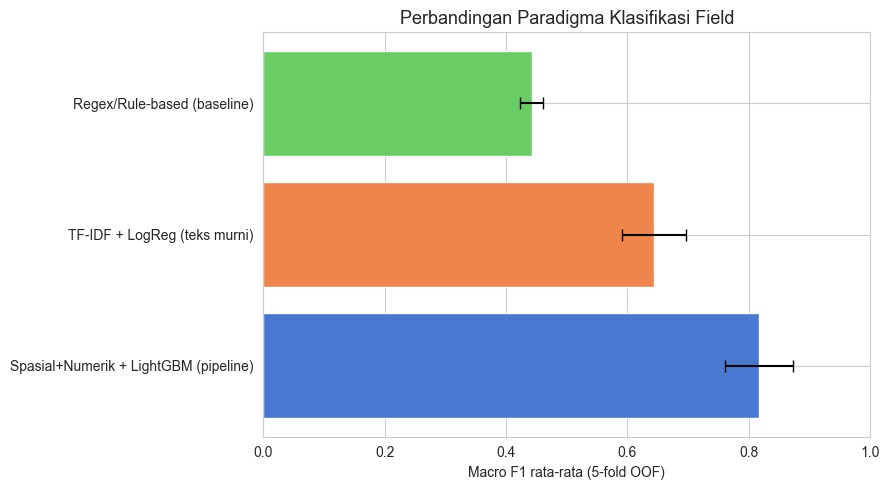

In [17]:
summary_paradigm = df_paradigm_comparison.groupby('approach')['macro_f1'].agg(['mean', 'std']).reset_index()
summary_paradigm = summary_paradigm.sort_values('mean', ascending=False)
print(summary_paradigm.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette(PALETTE, len(summary_paradigm))
ax.barh(summary_paradigm['approach'], summary_paradigm['mean'],
        xerr=summary_paradigm['std'], capsize=4, color=colors)
ax.set_xlabel('Macro F1 rata-rata (5-fold OOF)')
ax.set_title('Perbandingan Paradigma Klasifikasi Field')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(COMPARISON_DIR, 'text_paradigm_comparison.png'), dpi=100)
plt.show()


## 5. Ringkasan Perbandingan Keseluruhan

Sel di bawah menggabungkan seluruh hasil perbandingan menjadi satu tabel ringkas yang bisa langsung dikutip di laporan/slide final project. Isi baris "Kesimpulan" secara manual setelah melihat angka aktual di environment kamu -- notebook ini hanya menyiapkan kerangka dan angkanya, argumentasi bisnis/teknisnya tetap perlu kamu tulis sendiri.

In [18]:
summary_lines = []

if 'comparison_quality' in dir():
    summary_lines.append(['Lokalisasi Dokumen', 'DocAligner vs Heuristik CV Klasik',
                           f"Sukses klasik: {success_rate:.1%} | Blur DocAligner: {df['crop_blur_score'].mean():.1f} vs Klasik: {df_classical['blur_score'].mean():.1f}"])

if 'summary_ocr' in dir() and not summary_ocr.empty:
    best_ocr = summary_ocr['cer_mean'].idxmin()
    summary_lines.append(['OCR Engine', 'PaddleOCR vs EasyOCR vs Tesseract',
                           f'CER terendah: {best_ocr} ({summary_ocr.loc[best_ocr, "cer_mean"]:.3f})'])

if 'summary_model' in dir():
    best_model = summary_model.loc[summary_model['macro_f1_mean'].idxmax(), 'model']
    best_f1 = summary_model['macro_f1_mean'].max()
    summary_lines.append(['Model Klasifikasi Field', 'LightGBM vs RandomForest vs XGBoost',
                           f'Macro F1 tertinggi: {best_model} ({best_f1:.3f})'])

if 'summary_paradigm' in dir():
    best_approach = summary_paradigm.iloc[0]['approach']
    best_f1_p = summary_paradigm.iloc[0]['mean']
    summary_lines.append(['Representasi Teks', 'TF-IDF+LogReg vs Spasial+LightGBM vs Regex',
                           f'Macro F1 tertinggi: {best_approach} ({best_f1_p:.3f})'])

df_final_summary = pd.DataFrame(summary_lines, columns=['Aspek', 'Yang Dibandingkan', 'Hasil Ringkas'])
df_final_summary.to_csv(os.path.join(COMPARISON_DIR, 'final_summary.csv'), index=False)
print(df_final_summary.to_string(index=False))


                  Aspek                          Yang Dibandingkan                                                     Hasil Ringkas
     Lokalisasi Dokumen          DocAligner vs Heuristik CV Klasik     Sukses klasik: 3.5% | Blur DocAligner: 145.7 vs Klasik: 177.5
Model Klasifikasi Field        LightGBM vs RandomForest vs XGBoost                               Macro F1 tertinggi: XGBoost (0.818)
      Representasi Teks TF-IDF+LogReg vs Spasial+LightGBM vs Regex Macro F1 tertinggi: Spasial+Numerik + LightGBM (pipeline) (0.817)
